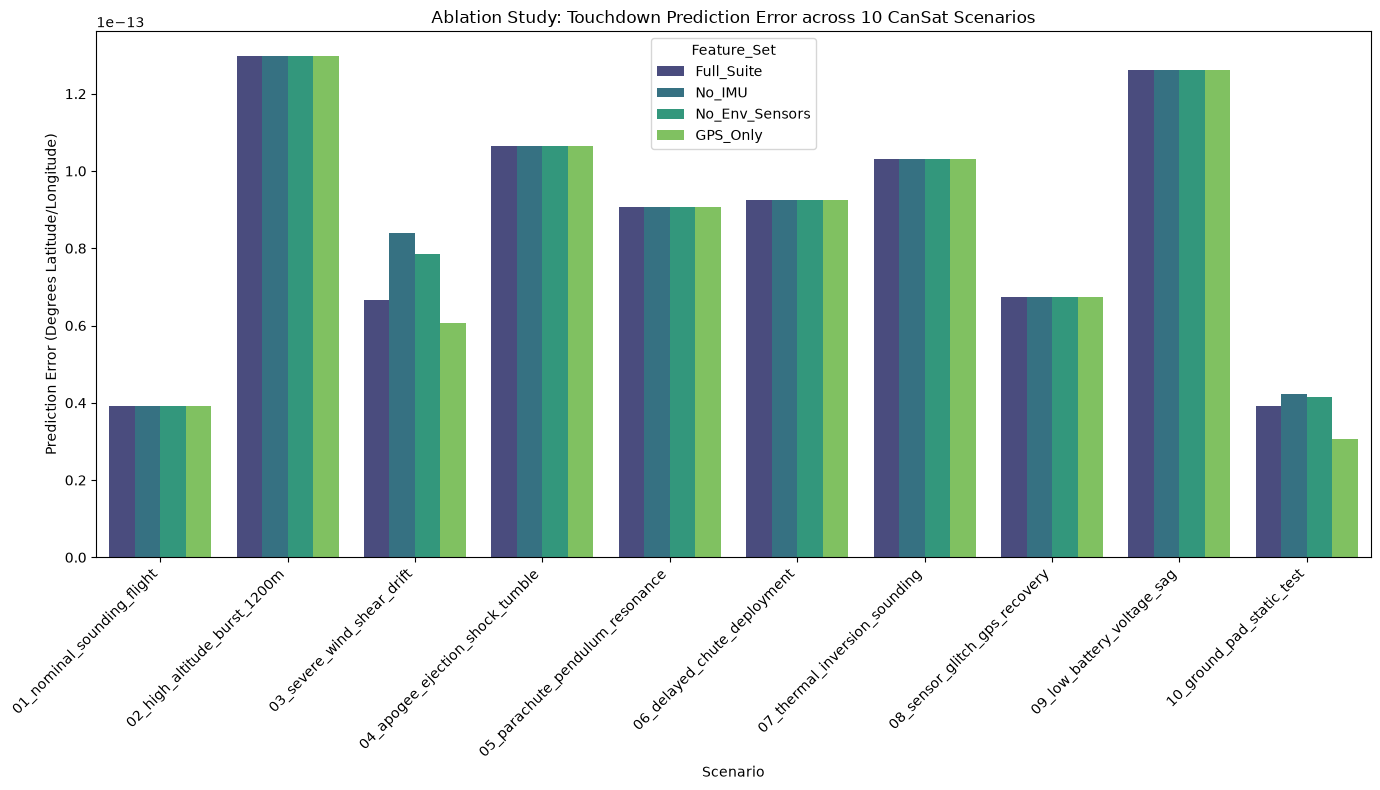

Mean Absolute Error (Degrees) by Scenario and Sensor Suite:
Feature_Set                        Full_Suite      GPS_Only  No_Env_Sensors  \
Scenario                                                                      
01_nominal_sounding_flight       3.907985e-14  3.907985e-14    3.907985e-14   
02_high_altitude_burst_1200m     1.296740e-13  1.296740e-13    1.296740e-13   
03_severe_wind_shear_drift       6.664891e-14  6.070403e-14    7.860971e-14   
04_apogee_ejection_shock_tumble  1.065814e-13  1.065814e-13    1.065814e-13   
05_parachute_pendulum_resonance  9.059420e-14  9.059420e-14    9.059420e-14   
06_delayed_chute_deployment      9.237056e-14  9.237056e-14    9.237056e-14   
07_thermal_inversion_sounding    1.030287e-13  1.030287e-13    1.030287e-13   
08_sensor_glitch_gps_recovery    6.750156e-14  6.750156e-14    6.750156e-14   
09_low_battery_voltage_sag       1.261213e-13  1.261213e-13    1.261213e-13   
10_ground_pad_static_test        3.927722e-14  3.067176e-14    4.160622

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import metpy.calc as mpcalc
from metpy.units import units
import warnings
warnings.filterwarnings('ignore')

# 10 CanSat flight scenarios
test_cases = [
    "01_nominal_sounding_flight.csv",
    "02_high_altitude_burst_1200m.csv",
    "03_severe_wind_shear_drift.csv",
    "04_apogee_ejection_shock_tumble.csv",
    "05_parachute_pendulum_resonance.csv",
    "06_delayed_chute_deployment.csv",
    "07_thermal_inversion_sounding.csv",
    "08_sensor_glitch_gps_recovery.csv",
    "09_low_battery_voltage_sag.csv",
    "10_ground_pad_static_test.csv"
]

feature_groups = {
    'Full_Suite': ['lat', 'lon', 'Altitude_m', 'Pressure_Pa', 'Temp_C', 'Accel_Z_m_s2', 'Potential_Temp_K'],
    'No_IMU': ['lat', 'lon', 'Altitude_m', 'Pressure_Pa', 'Temp_C', 'Potential_Temp_K'],
    'No_Env_Sensors': ['lat', 'lon', 'Altitude_m', 'Accel_Z_m_s2'],
    'GPS_Only': ['lat', 'lon', 'Altitude_m']
}

all_results = []

for case in test_cases:
    # 1. Load dataset (handles execution from either root or test_cases/)
    file_path = case if os.path.exists(case) else os.path.join("test_cases", case)
    df = pd.read_csv(file_path)
        
    # Forward/backward fill any NaNs (e.g., GPS dropouts in scenario 08)
    df = df.bfill().ffill()
    
    # Map raw CSV columns to expected feature names and SI units
    df['Altitude_m']   = df['altitude']
    df['Pressure_Pa']  = df['pressure'] * 100.0   # Convert hPa to Pa
    df['Temp_C']       = df['temp']               # Celsius
    df['Accel_Z_m_s2'] = df['az'] * 9.80665       # Convert g to m/s²
    
    # Define Target: Final Landing Coordinates
    df['Target_Touchdown_Lat'] = df['lat'].iloc[-1]
    df['Target_Touchdown_Lon'] = df['lon'].iloc[-1]
    
    # 2. MetPy Atmospheric Calculations
    pressure_units = df['Pressure_Pa'].values * units.pascal
    temperature_units = df['Temp_C'].values * units.degC
    df['Potential_Temp_K'] = mpcalc.potential_temperature(pressure_units, temperature_units).to('kelvin').m
    
    # 3. Ablation Study Pipeline
    y = df[['Target_Touchdown_Lat', 'Target_Touchdown_Lon']]
    
    for group_name, features in feature_groups.items():
        X = df[features]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Train Touchdown Regressor
        model = RandomForestRegressor(n_estimators=20, random_state=42)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        # Evaluate Error (Mean Absolute Error in Degrees)
        mae = mean_absolute_error(y_test, predictions)
        
        all_results.append({
            'Scenario': case.replace('.csv', ''),
            'Feature_Set': group_name,
            'MAE_Degrees': mae
        })

# 4. Aggregation and Visualization
results_df = pd.DataFrame(all_results)

plt.figure(figsize=(14, 8))
sns.barplot(data=results_df, x='Scenario', y='MAE_Degrees', hue='Feature_Set', palette='viridis')
plt.title('Ablation Study: Touchdown Prediction Error across 10 CanSat Scenarios')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Prediction Error (Degrees Latitude/Longitude)')
plt.tight_layout()
plt.show()

# Print numerical summary matrix
print("Mean Absolute Error (Degrees) by Scenario and Sensor Suite:")
print(results_df.groupby(['Scenario', 'Feature_Set'])['MAE_Degrees'].mean().unstack())